In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

from scipy.integrate import trapezoid
from scipy.optimize import curve_fit

from calcium_analysis.peaks import (
    get_peak_positions_and_properties,
    get_timeseries_per_spike_df,
    append_segment_bounds_using_relative_prominence,
    append_segment_bounds_using_local_minima,
)

from calcium_analysis.smoothing import (
    rolling_quantile,
    rolling_gaussian_mean,
)
from calcium_analysis.fitting import fit_exponential_decay_per_spike

from calcium_analysis.plot import (
    plot_traces_by_rowcol,
    _trace_to_frame)

# Read data from excel and convert to "standard" format

In [2]:
fps = 11
DT = 1 / fps

In [3]:
df = pd.read_excel("/Users/mariaclaudia/Downloads/test_scOscillations.xlsx")
df

,Row,Column,Timepoint,Object ID,Tracked Loaded Population - Intensity Cell th/Fluo-4 Mean,Cell Type,Compound,Concentration
0,2,2,1,25,554.125,c1,LTX1,0
1,2,2,2,25,563.279,c1,LTX1,0
2,2,2,3,25,557.382,c1,LTX1,0
3,2,2,4,25,551.346,c1,LTX1,0
4,2,2,5,25,557.500,c1,LTX1,0
...,...,...,...,...,...,...,...,...
985,2,3,326,38,325.787,g1,LTX1,0
986,2,3,327,38,321.840,g1,LTX1,0
987,2,3,328,38,322.027,g1,LTX1,0
988,2,3,329,38,328.080,g1,LTX1,0


In [4]:
time = df["Timepoint"] * DT
df["Timepoint"] = time
df = df.rename(
    columns={
        "Timepoint": "time",
        "Tracked Loaded Population - Intensity Cell th/Fluo-4 Mean": "value",
    }
)
df = df.set_index(["Row", "Column", "Object ID", "time"])

In [5]:
'''df
plot_df = df.loc[(2, 2, 25), "value"]   # this returns a Series indexed by time
plot_df.plot()'''


'df\nplot_df = df.loc[(2, 2, 25), "value"]   # this returns a Series indexed by time\nplot_df.plot()'

# Subract baseline, normalize, and smooth

In [6]:
baseline = rolling_quantile(df["value"], quantile=0.1, window_size=100, center=True, min_periods=50)

normalized_value = df["value"] / baseline - 1

smoothed_normalized = rolling_gaussian_mean(
    normalized_value,
    kernel_width=5,
    kernel_sigma=2,
)

In [7]:
'''key = (2, 2, 25)
# extract time series from df and baseline in a safe way
raw_series = df['value'].xs(key, level=('Row', 'Column', 'Object ID'))   # original raw intensity
baseline_series = baseline.xs(key, level=('Row', 'Column', 'Object ID'))

# make sure they align on the same time index
raw_series = raw_series.sort_index()
baseline_series = baseline_series.sort_index()

# compute normalized (if you want to plot it)
normalized_series = raw_series / baseline_series - 1

plt.figure(figsize=(10,4))
ax = raw_series.plot(label='raw', alpha=0.6)
baseline_series.plot(label='baseline', linewidth=2)
#normalized_series.plot(ax=ax, label='normalized (raw/baseline - 1)', secondary_y=True, linestyle='--')
ax.set_xlabel('time')
ax.set_ylabel('Intensity')
ax.legend(loc='upper left')
plt.title('Raw vs Baseline (left axis) and Normalized (right axis)')
plt.show()'''

"key = (2, 2, 25)\n# extract time series from df and baseline in a safe way\nraw_series = df['value'].xs(key, level=('Row', 'Column', 'Object ID'))   # original raw intensity\nbaseline_series = baseline.xs(key, level=('Row', 'Column', 'Object ID'))\n\n# make sure they align on the same time index\nraw_series = raw_series.sort_index()\nbaseline_series = baseline_series.sort_index()\n\n# compute normalized (if you want to plot it)\nnormalized_series = raw_series / baseline_series - 1\n\nplt.figure(figsize=(10,4))\nax = raw_series.plot(label='raw', alpha=0.6)\nbaseline_series.plot(label='baseline', linewidth=2)\n#normalized_series.plot(ax=ax, label='normalized (raw/baseline - 1)', secondary_y=True, linestyle='--')\nax.set_xlabel('time')\nax.set_ylabel('Intensity')\nax.legend(loc='upper left')\nplt.title('Raw vs Baseline (left axis) and Normalized (right axis)')\nplt.show()"

# Compile a Dataframe with various properties for each peak

In [8]:
peaks_and_properties = get_peak_positions_and_properties(
    smoothed_normalized,
    height_z_score_threshold=3,
    prominence_threshold_over_sigma=2,
    min_delta_t=2,
    rel_prominences_for_widths=[0.5, 0.75],
)


metadata_to_add = df.groupby(level=["Row", "Column", "Object ID"])[
    ["Compound", "Concentration", "Cell Type"]
].first()
peaks_and_properties = peaks_and_properties.merge(
    metadata_to_add, left_index=True, right_index=True, how="left"
)

In [9]:
peaks_and_properties

peak_heights  prominences  left_bases  \
Row Column Object ID peak_index                                          
2   2      1         0               0.058550     0.058733         246   
    3      38        0               0.423079     0.422291         128   
                     1               0.394617     0.393428         221   

                                 right_bases  peak_centers_seconds  \
Row Column Object ID peak_index                                      
2   2      1         0                   329             24.000000   
    3      38        0                   310             13.000000   
                     1                   310             22.818182   

                                 peak_centers_idx   width_50  \
Row Column Object ID peak_index                                
2   2      1         0                        263  37.133466   
    3      38        0                        142  14.256405   
                     1                        250  31.025678   

                                 width_50_start_idx  width_50_end_idx  \
Row Column Object ID peak_index                                         
2   2      1         0                          252               289   
    3      38        0                          137               151   
                     1                          229               260   

                                 width_50_start_time  width_50_end_time  \
Row Column Object ID peak_index                                           
2   2      1         0                     23.000000          26.363636   
    3      38        0                     12.545455          13.818182   
                     1                     20.909091          23.727273   

                                  width_75  width_75_start_idx  \
Row Column Object ID peak_index                                  
2   2      1         0           47.487502                 251   
    3      38        0           24.668844                 136   
                     1           40.405943                 227   

                                 width_75_end_idx  width_75_start_time  \
Row Column Object ID peak_index                                          
2   2      1         0                        299            22.909091   
    3      38        0                        160            12.454545   
                     1                        268            20.727273   

                                 width_75_end_time Compound  Concentration  \
Row Column Object ID peak_index                                              
2   2      1         0                   27.272727     LTX1              0   
    3      38        0                   14.636364     LTX1              0   
                     1                   24.454545     LTX1              0   

                                Cell Type  
Row Column Object ID peak_index            
2   2      1         0                 c1  
    3      38        0                 g1  
                     1                 g1

# Compile a DataFrame with the signal segment corresponding to each peak

## Option 1: using relative prominence to determine the segment boundary

In [10]:
peaks_and_properties = append_segment_bounds_using_relative_prominence(
    peaks_and_properties,
    smoothed_normalized,
    rel_prominence=0.75,
)
peaks_timeseries = get_timeseries_per_spike_df(
    smoothed_normalized, peaks_and_properties
)

In [11]:
peaks_and_properties

peak_heights  prominences  left_bases  \
Row Column Object ID peak_index                                          
2   2      1         0               0.058550     0.058733         246   
    3      38        0               0.423079     0.422291         128   
                     1               0.394617     0.393428         221   

                                 right_bases  peak_centers_seconds  \
Row Column Object ID peak_index                                      
2   2      1         0                   329             24.000000   
    3      38        0                   310             13.000000   
                     1                   310             22.818182   

                                 peak_centers_idx   width_50  \
Row Column Object ID peak_index                                
2   2      1         0                        263  37.133466   
    3      38        0                        142  14.256405   
                     1                        250  31.025678   

                                 width_50_start_idx  width_50_end_idx  \
Row Column Object ID peak_index                                         
2   2      1         0                          252               289   
    3      38        0                          137               151   
                     1                          229               260   

                                 width_50_start_time  ...  width_75_start_idx  \
Row Column Object ID peak_index                       ...                       
2   2      1         0                     23.000000  ...                 251   
    3      38        0                     12.545455  ...                 136   
                     1                     20.909091  ...                 227   

                                 width_75_end_idx  width_75_start_time  \
Row Column Object ID peak_index                                          
2   2      1         0                        299            22.909091   
    3      38        0                        160            12.454545   
                     1                        268            20.727273   

                                 width_75_end_time  Compound  Concentration  \
Row Column Object ID peak_index                                               
2   2      1         0                   27.272727      LTX1              0   
    3      38        0                   14.636364      LTX1              0   
                     1                   24.454545      LTX1              0   

                                Cell Type  segment_start_idx segment_end_idx  \
Row Column Object ID peak_index                                                
2   2      1         0                 c1                251             299   
    3      38        0                 g1                136             160   
                     1                 g1                227             268   

                                 segment_truncated  
Row Column Object ID peak_index                     
2   2      1         0                       False  
    3      38        0                       False  
                     1                       False  

[3 rows x 22 columns]

In [12]:
#peaks_and_properties

## Option 2: using local minima to determine the segment boundary

In [13]:
peaks_and_properties = append_segment_bounds_using_local_minima(
    peaks_and_properties,
    smoothed_normalized,
)
peaks_timeseries_alt = get_timeseries_per_spike_df(
    smoothed_normalized, peaks_and_properties
)

In [14]:
peaks_and_properties

peak_heights  prominences  left_bases  \
Row Column Object ID peak_index                                          
2   2      1         0               0.058550     0.058733         246   
    3      38        0               0.423079     0.422291         128   
                     1               0.394617     0.393428         221   

                                 right_bases  peak_centers_seconds  \
Row Column Object ID peak_index                                      
2   2      1         0                   329             24.000000   
    3      38        0                   310             13.000000   
                     1                   310             22.818182   

                                 peak_centers_idx   width_50  \
Row Column Object ID peak_index                                
2   2      1         0                        263  37.133466   
    3      38        0                        142  14.256405   
                     1                        250  31.025678   

                                 width_50_start_idx  width_50_end_idx  \
Row Column Object ID peak_index                                         
2   2      1         0                          252               289   
    3      38        0                          137               151   
                     1                          229               260   

                                 width_50_start_time  ...  width_75_start_idx  \
Row Column Object ID peak_index                       ...                       
2   2      1         0                     23.000000  ...                 251   
    3      38        0                     12.545455  ...                 136   
                     1                     20.909091  ...                 227   

                                 width_75_end_idx  width_75_start_time  \
Row Column Object ID peak_index                                          
2   2      1         0                        299            22.909091   
    3      38        0                        160            12.454545   
                     1                        268            20.727273   

                                 width_75_end_time  Compound  Concentration  \
Row Column Object ID peak_index                                               
2   2      1         0                   27.272727      LTX1              0   
    3      38        0                   14.636364      LTX1              0   
                     1                   24.454545      LTX1              0   

                                Cell Type  segment_start_idx segment_end_idx  \
Row Column Object ID peak_index                                                
2   2      1         0                 c1                258             270   
    3      38        0                 g1                134             175   
                     1                 g1                244             280   

                                 segment_truncated  
Row Column Object ID peak_index                     
2   2      1         0                       False  
    3      38        0                       False  
                     1                       False  

[3 rows x 22 columns]

In [15]:
peaks_timeseries_alt

signal_segment
Row Column Object ID peak_index time_from_peak                
2   2      1         0          -0.454545             0.038878
                                -0.363636             0.040187
                                -0.272727             0.044841
                                -0.181818             0.051639
                                -0.090909             0.056972
...                                                        ...
    3      38        1           2.363636             0.052157
                                 2.454545             0.045716
                                 2.545455             0.042174
                                 2.636364             0.040073
                                 2.727273             0.037195

[92 rows x 1 columns]

# Fit each peak decay as an exponential decay

In [16]:
decay_data = fit_exponential_decay_per_spike(
    peaks_timeseries_alt["signal_segment"]
).where(~peaks_and_properties["segment_truncated"])

In [17]:
decay_data

peak_over_baseline       tau  baseline  \
Row Column Object ID peak_index                                           
2   2      1         0                     0.362790  8.184200 -0.302605   
    3      38        0                     0.450904  1.261432 -0.006296   
                     1                     0.448559  1.530571 -0.044081   

                                 mean_square_error        r2  
Row Column Object ID peak_index                               
2   2      1         0                    0.000002  0.980110  
    3      38        0                    0.000045  0.996734  
                     1                    0.000016  0.998697

In [18]:
## Frequency
total_rec_time = (
    smoothed_normalized.groupby(["Row", "Column", "Object ID"]).count() * DT
)

freq = (peaks_and_properties.groupby(["Row", "Column", "Object ID"]).size() / total_rec_time)

# Nan correspond to no peaks -> frequency=0
freq = freq.fillna(0)

freq = freq.rename("Peak Frequency [Hz]")

In [19]:
freq

Row  Column  Object ID
2    2       1            0.033333
             25           0.000000
     3       38           0.066667
Name: Peak Frequency [Hz], dtype: float64

# Extracting a new property from the timeseries

## Example: AUC

In [20]:
from calcium_analysis.multiindex_decorators import (
    support_multiindex_signal_single_row_returns,
)


@support_multiindex_signal_single_row_returns(time_name="time_from_peak")
def auc_per_series(signal: pd.Series) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "AUC": trapezoid(signal.values, dx=DT),
            }
        ]
    )


auc = auc_per_series(peaks_timeseries_alt["signal_segment"])
auc

AUC
Row Column Object ID peak_index          
2   2      1         0           0.051600
    3      38        0           0.674631
                     1           0.620697

# Plot

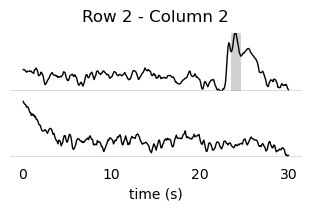

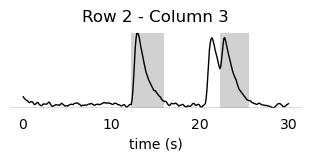

In [ ]:
plot_traces_by_rowcol(smoothed_normalized, peaks_and_properties, peak_span_color="#000000")
